Fisher's exact test is a statistical method used to determine if there are nonrandom associations between two categorical variables

In [2]:

import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

complex_labels = {
    "complex_i": "Complex I",
    "complex_ii": "Complex II",
    "complex_iii": "Complex III",
    "complex_iv": "Complex IV",
    "complex_v": "Complex V"
}


STRING_DIR = "../data/interim/STRING_output"

subtypes = [
    "classical",
    "mesenchymal",
    "proneural"
]

PATHWAY_DIR = "../data/processed/pathway_diff"
OXPHOS_DIR = "../data/processed/oxphos"

pathways = [
    "Apoptosis",
    "Autophagy",
    "Ferroptosis",
    "Necroptosis",
    "Pyroptosis"
]

complexes = [
    "complex_i",
    "complex_ii",
    "complex_iii",
    "complex_iv",
    "complex_v"
]

graphs = {}



for subtype in subtypes:

    from collections import defaultdict

    gene_annotation = defaultdict(lambda: {
        "pathways": set(),
        "complexes": set()
    })

    ####################################################
    # Load pathway annotations
    ####################################################
    
    for pathway in pathways:

        file = os.path.join(
            PATHWAY_DIR,
            subtype,
            f"{subtype}_{pathway}_diff.csv"
        )

        df = pd.read_csv(file, index_col=0)

        df.index = df.index.astype(str).str.upper()

        for gene in df.index:
            gene_annotation[gene]["pathways"].add(pathway)

    
    ####################################################
    # Load complex annotations
    ####################################################

    for complex_name in complexes:

        file = os.path.join(
            OXPHOS_DIR,
            subtype,
            f"{subtype}_{complex_name}.csv"
        )

        df = pd.read_csv(file, index_col=0)

        df.index = df.index.astype(str).str.upper()

        for gene in df.index:
            gene_annotation[gene]["complexes"].add(
                complex_labels[complex_name]
            )

    ####################################################
    # Load STRING network
    ####################################################

    file = os.path.join(
        STRING_DIR,
        f"{subtype}_string_interactions.tsv"
    )

    interactions = pd.read_csv(
        file,
        sep="\t"
    )

    G = nx.from_pandas_edgelist(
        interactions,
        source="#node1",
        target="node2",
        edge_attr=True,
        create_using=nx.Graph()
    )

    graphs[subtype] = G

    for gene in G.nodes():
        G.nodes[gene]["Pathways"] = list(
            gene_annotation[gene]["pathways"]
        )

        G.nodes[gene]["Complexes"] = list(
            gene_annotation[gene]["complexes"]
        )

    annotation = []

    for gene in G.nodes():

        annotation.append({

            "Gene": gene,

            "Pathways": ";".join(G.nodes[gene]["Pathways"]),

            "Complexes": ";".join(G.nodes[gene]["Complexes"])

        })

    annotation = pd.DataFrame(annotation)

    annotation.to_csv(
        f"../data/interim/network_stat/{subtype}_annotations.csv",
        index=False
    )
    

    
    degree = dict(G.degree())
    betweenness = nx.betweenness_centrality(G)
    closeness = nx.closeness_centrality(G)
    pagerank = nx.pagerank(G)

    stats = pd.DataFrame({
        "Gene": list(G.nodes()),
        "Degree": [degree[g] for g in G.nodes()],
        "Betweenness": [betweenness[g] for g in G.nodes()],
        "Closeness": [closeness[g] for g in G.nodes()],
        "PageRank": [pagerank[g] for g in G.nodes()]
    })

    stats.sort_values(
        "Degree",
        ascending=False
    ).to_csv(
        os.path.join(

            f"../data/interim/network_stat/{subtype}_network_statistics.csv"
        ),
        index=False
    )
    print(f"{subtype.capitalize()}")
    print(f"Nodes : {G.number_of_nodes()}")
    print(f"Edges : {G.number_of_edges()}")
    print("-" * 30)


Classical
Nodes : 218
Edges : 5288
------------------------------
Mesenchymal
Nodes : 240
Edges : 5544
------------------------------
Proneural
Nodes : 203
Edges : 4989
------------------------------


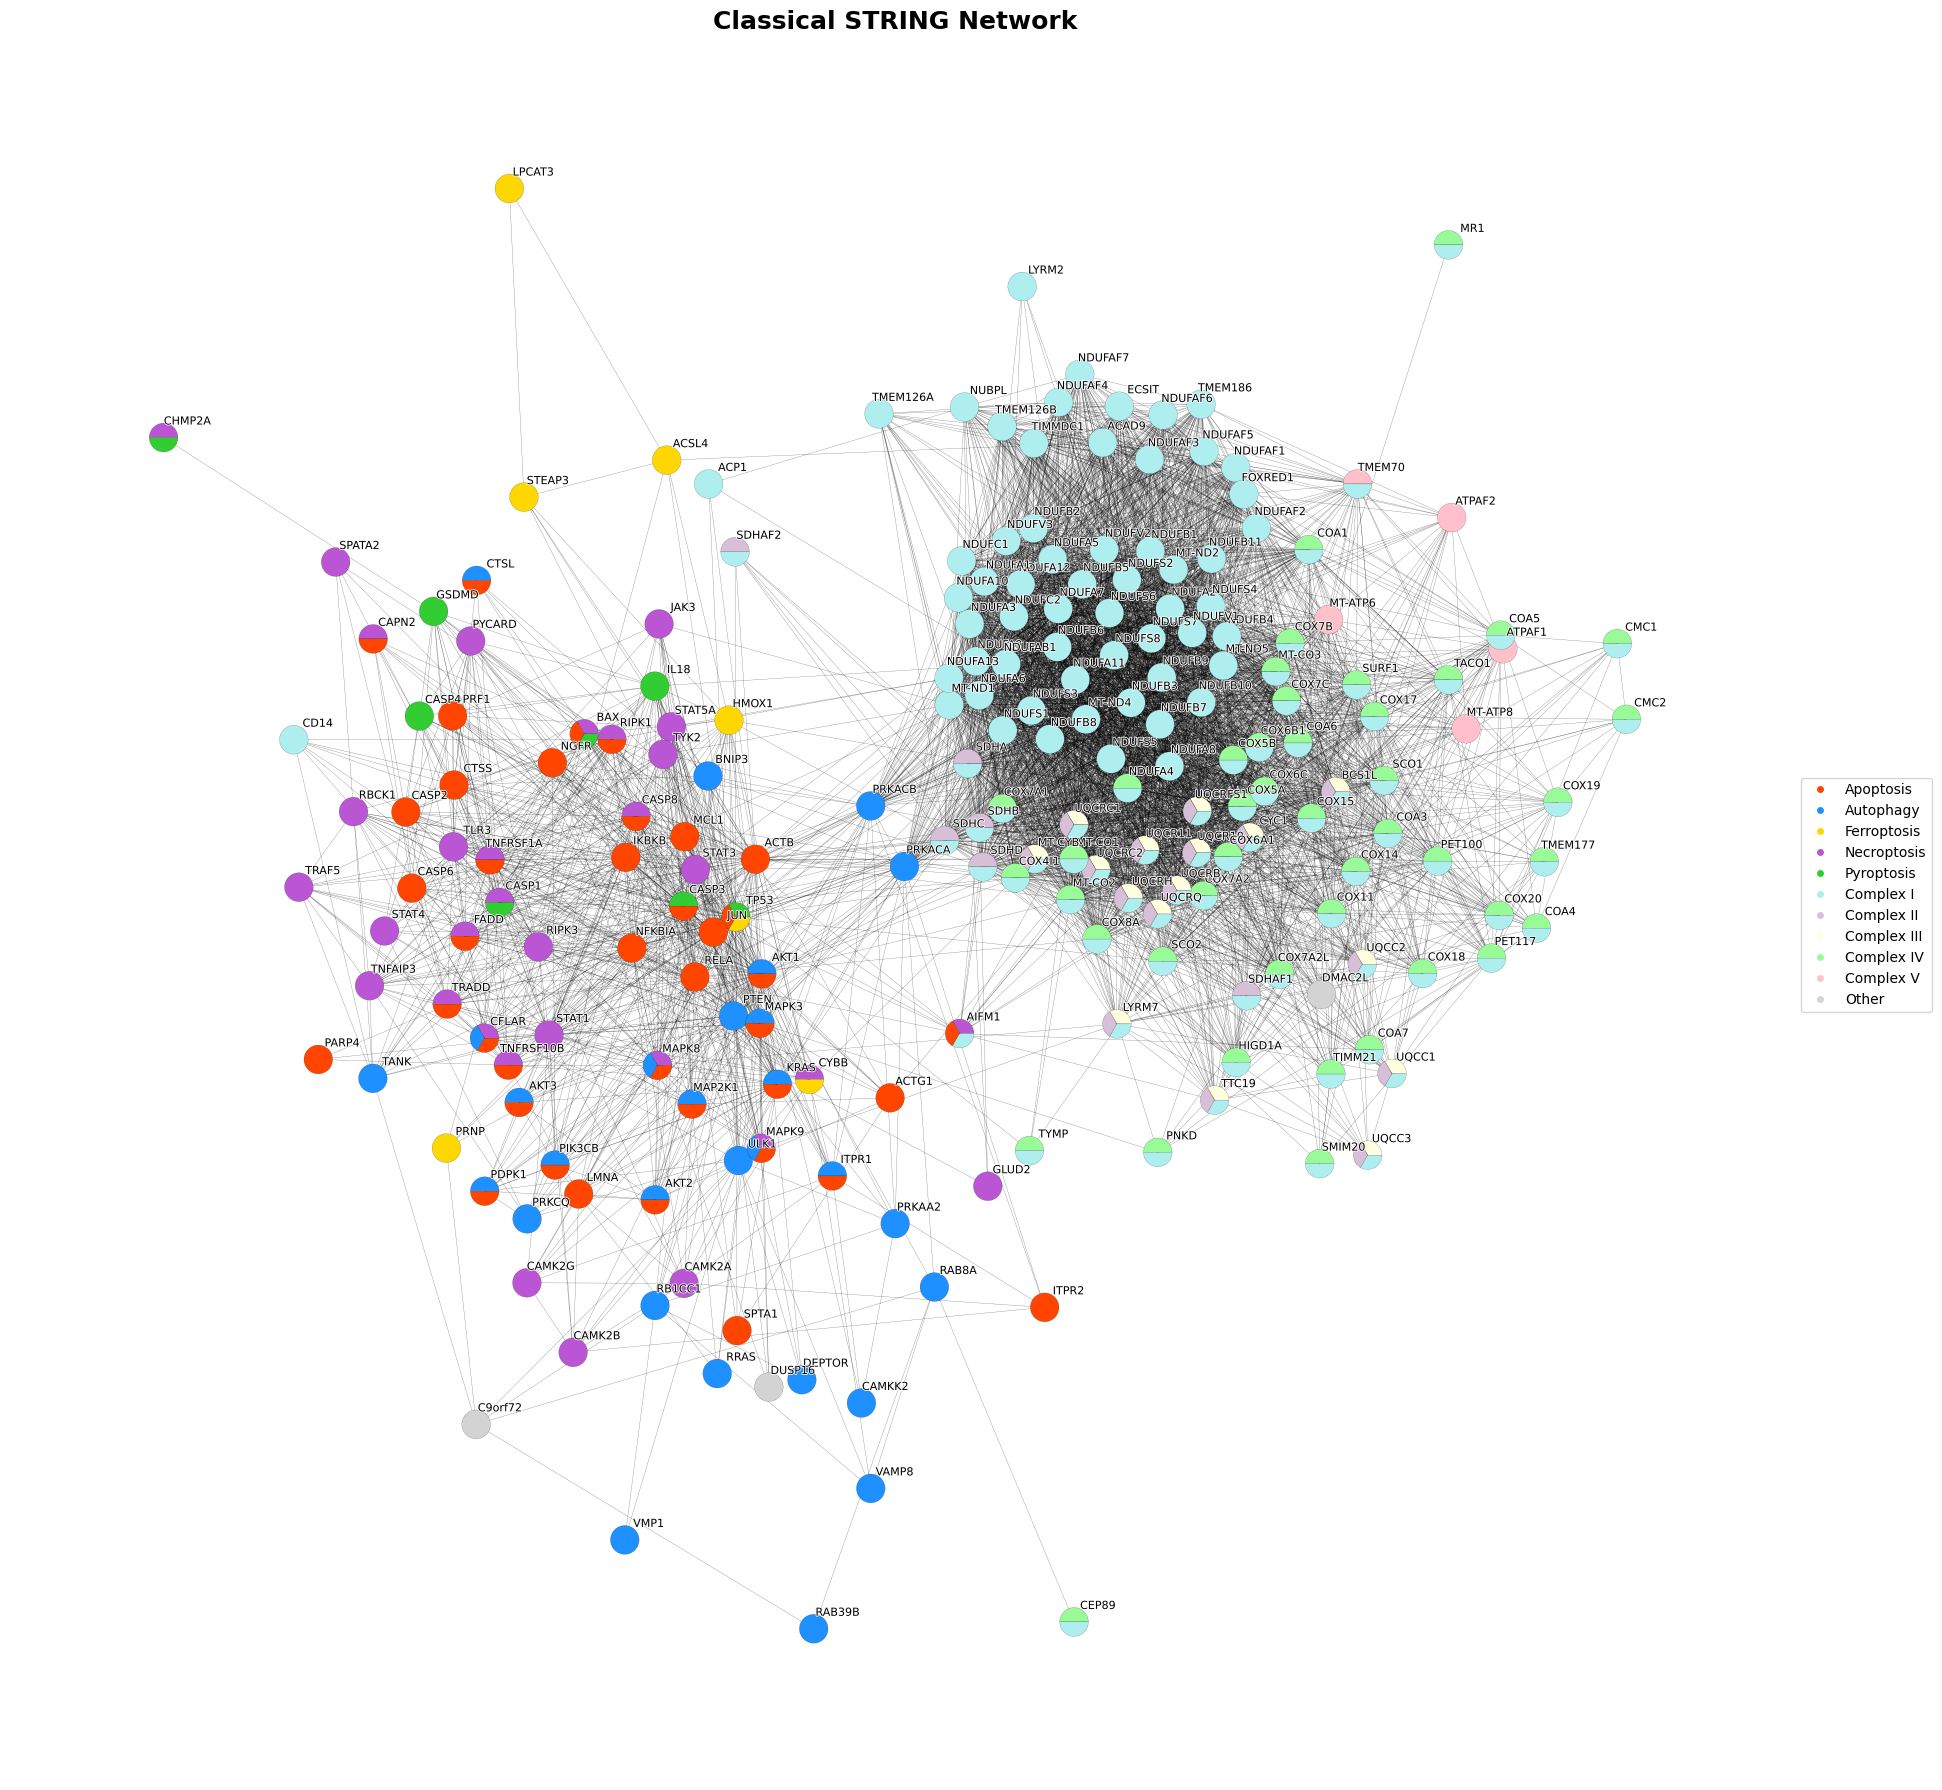

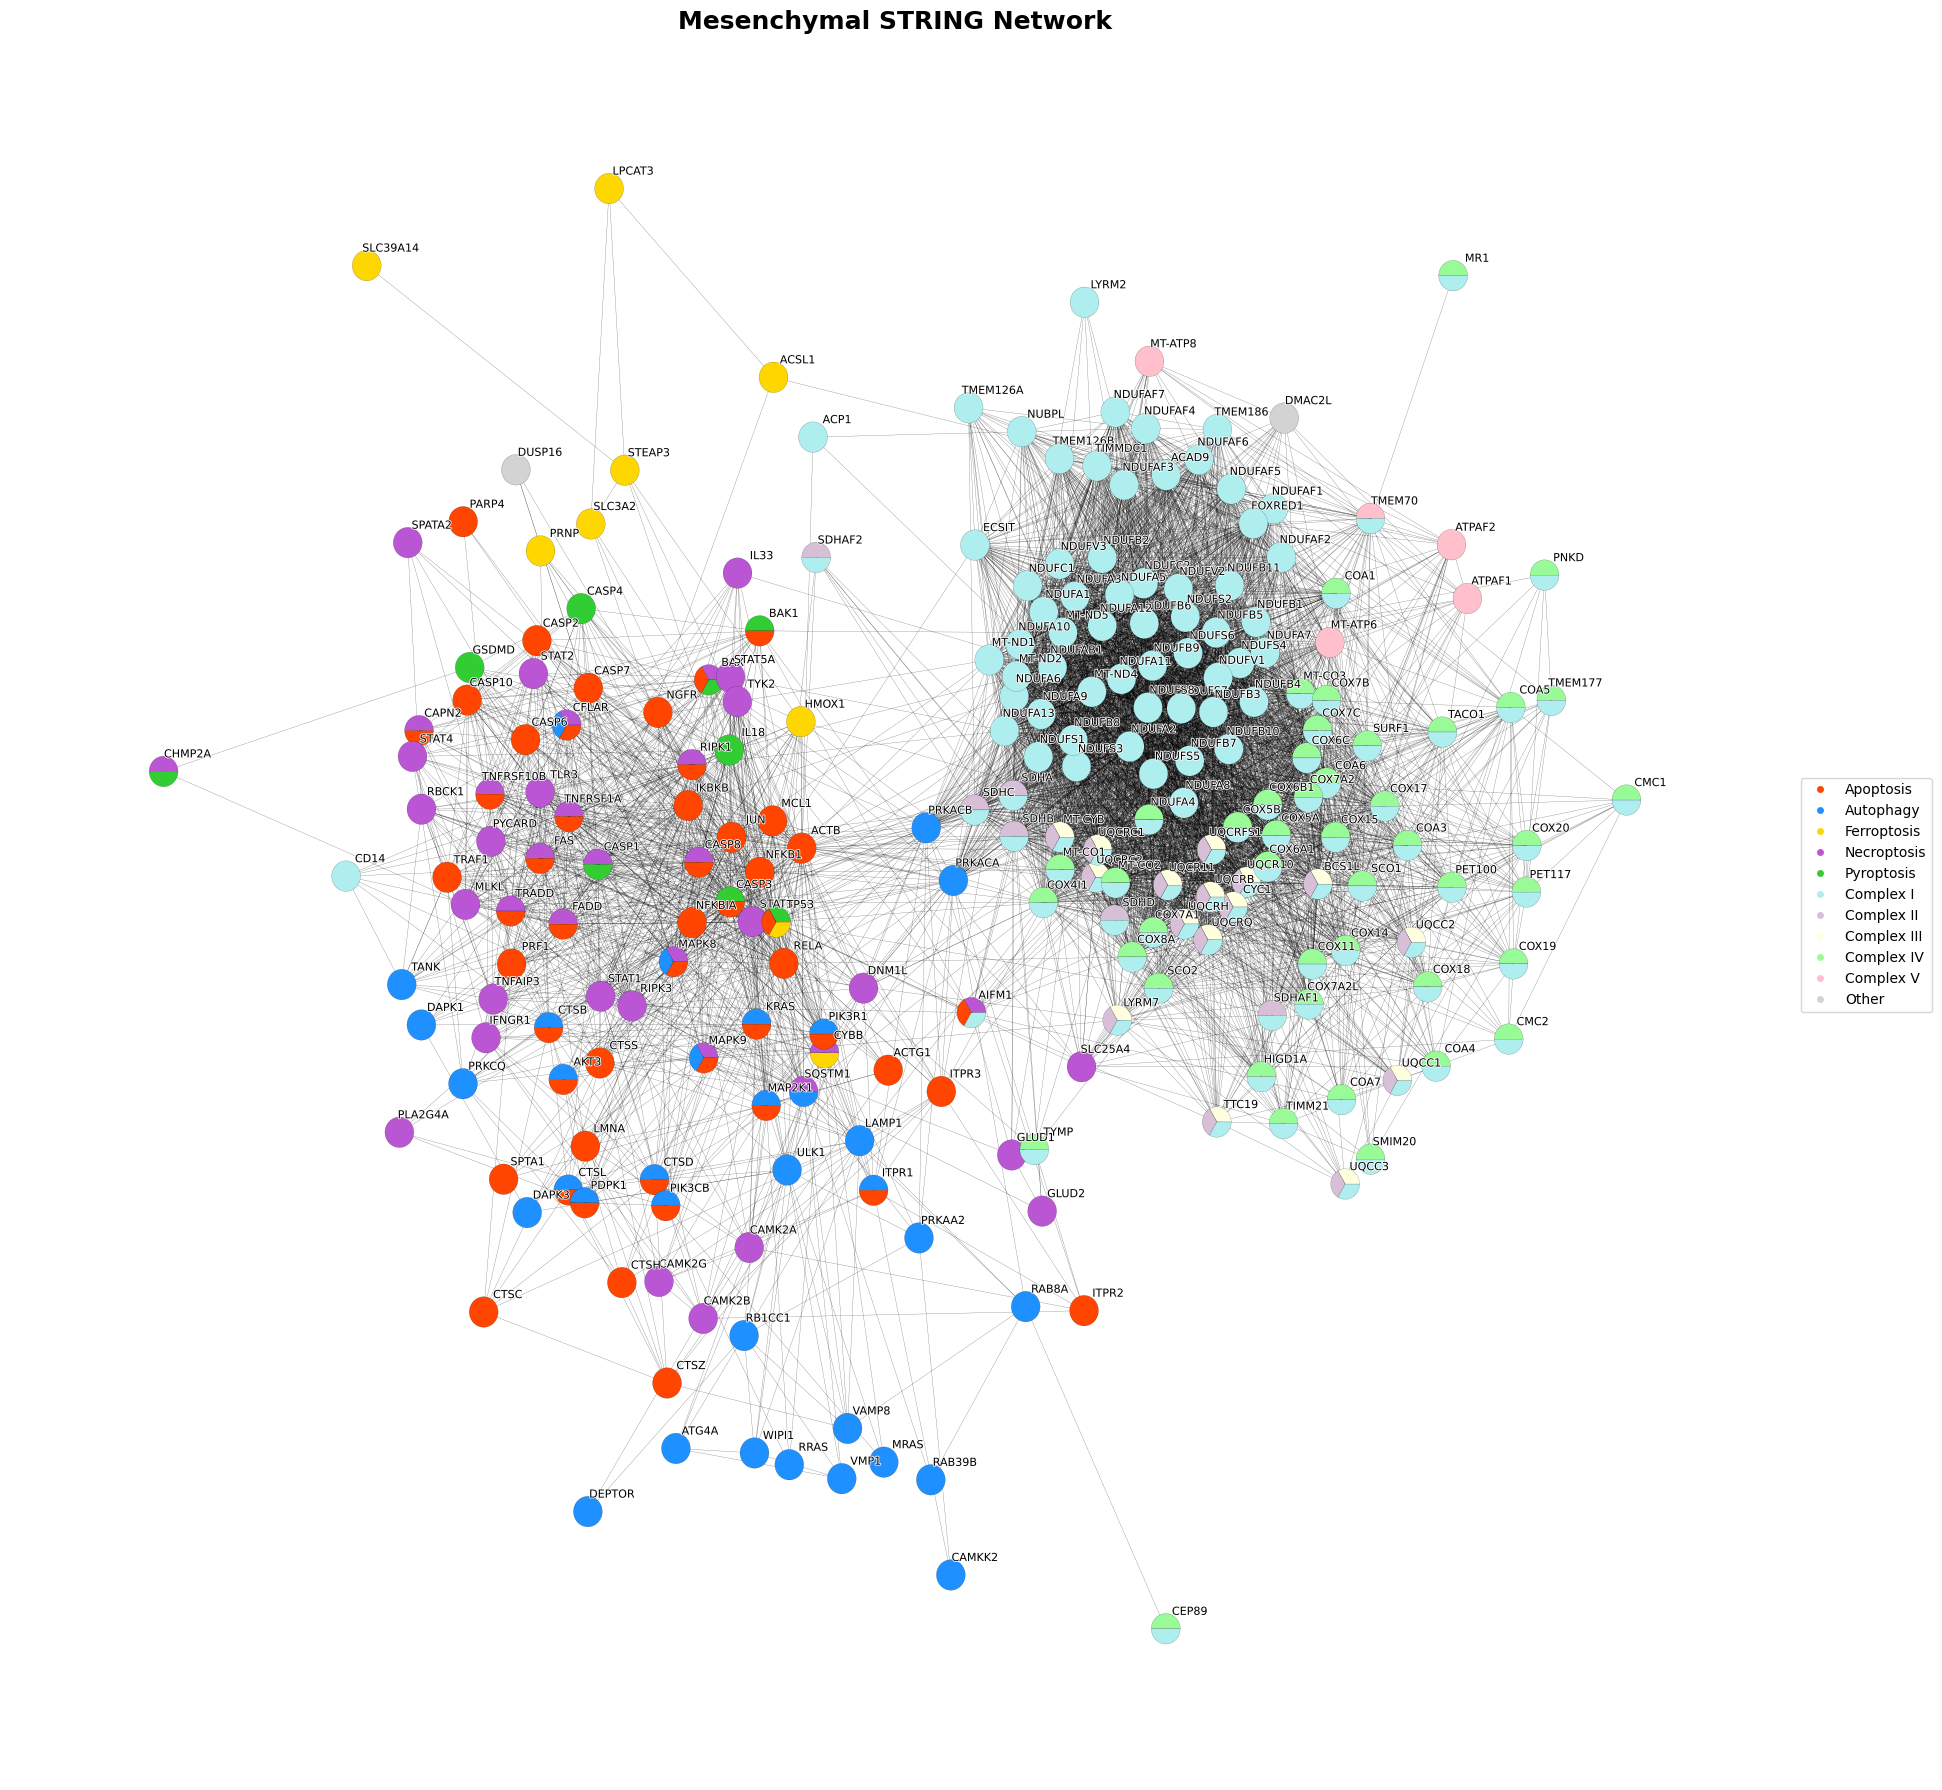

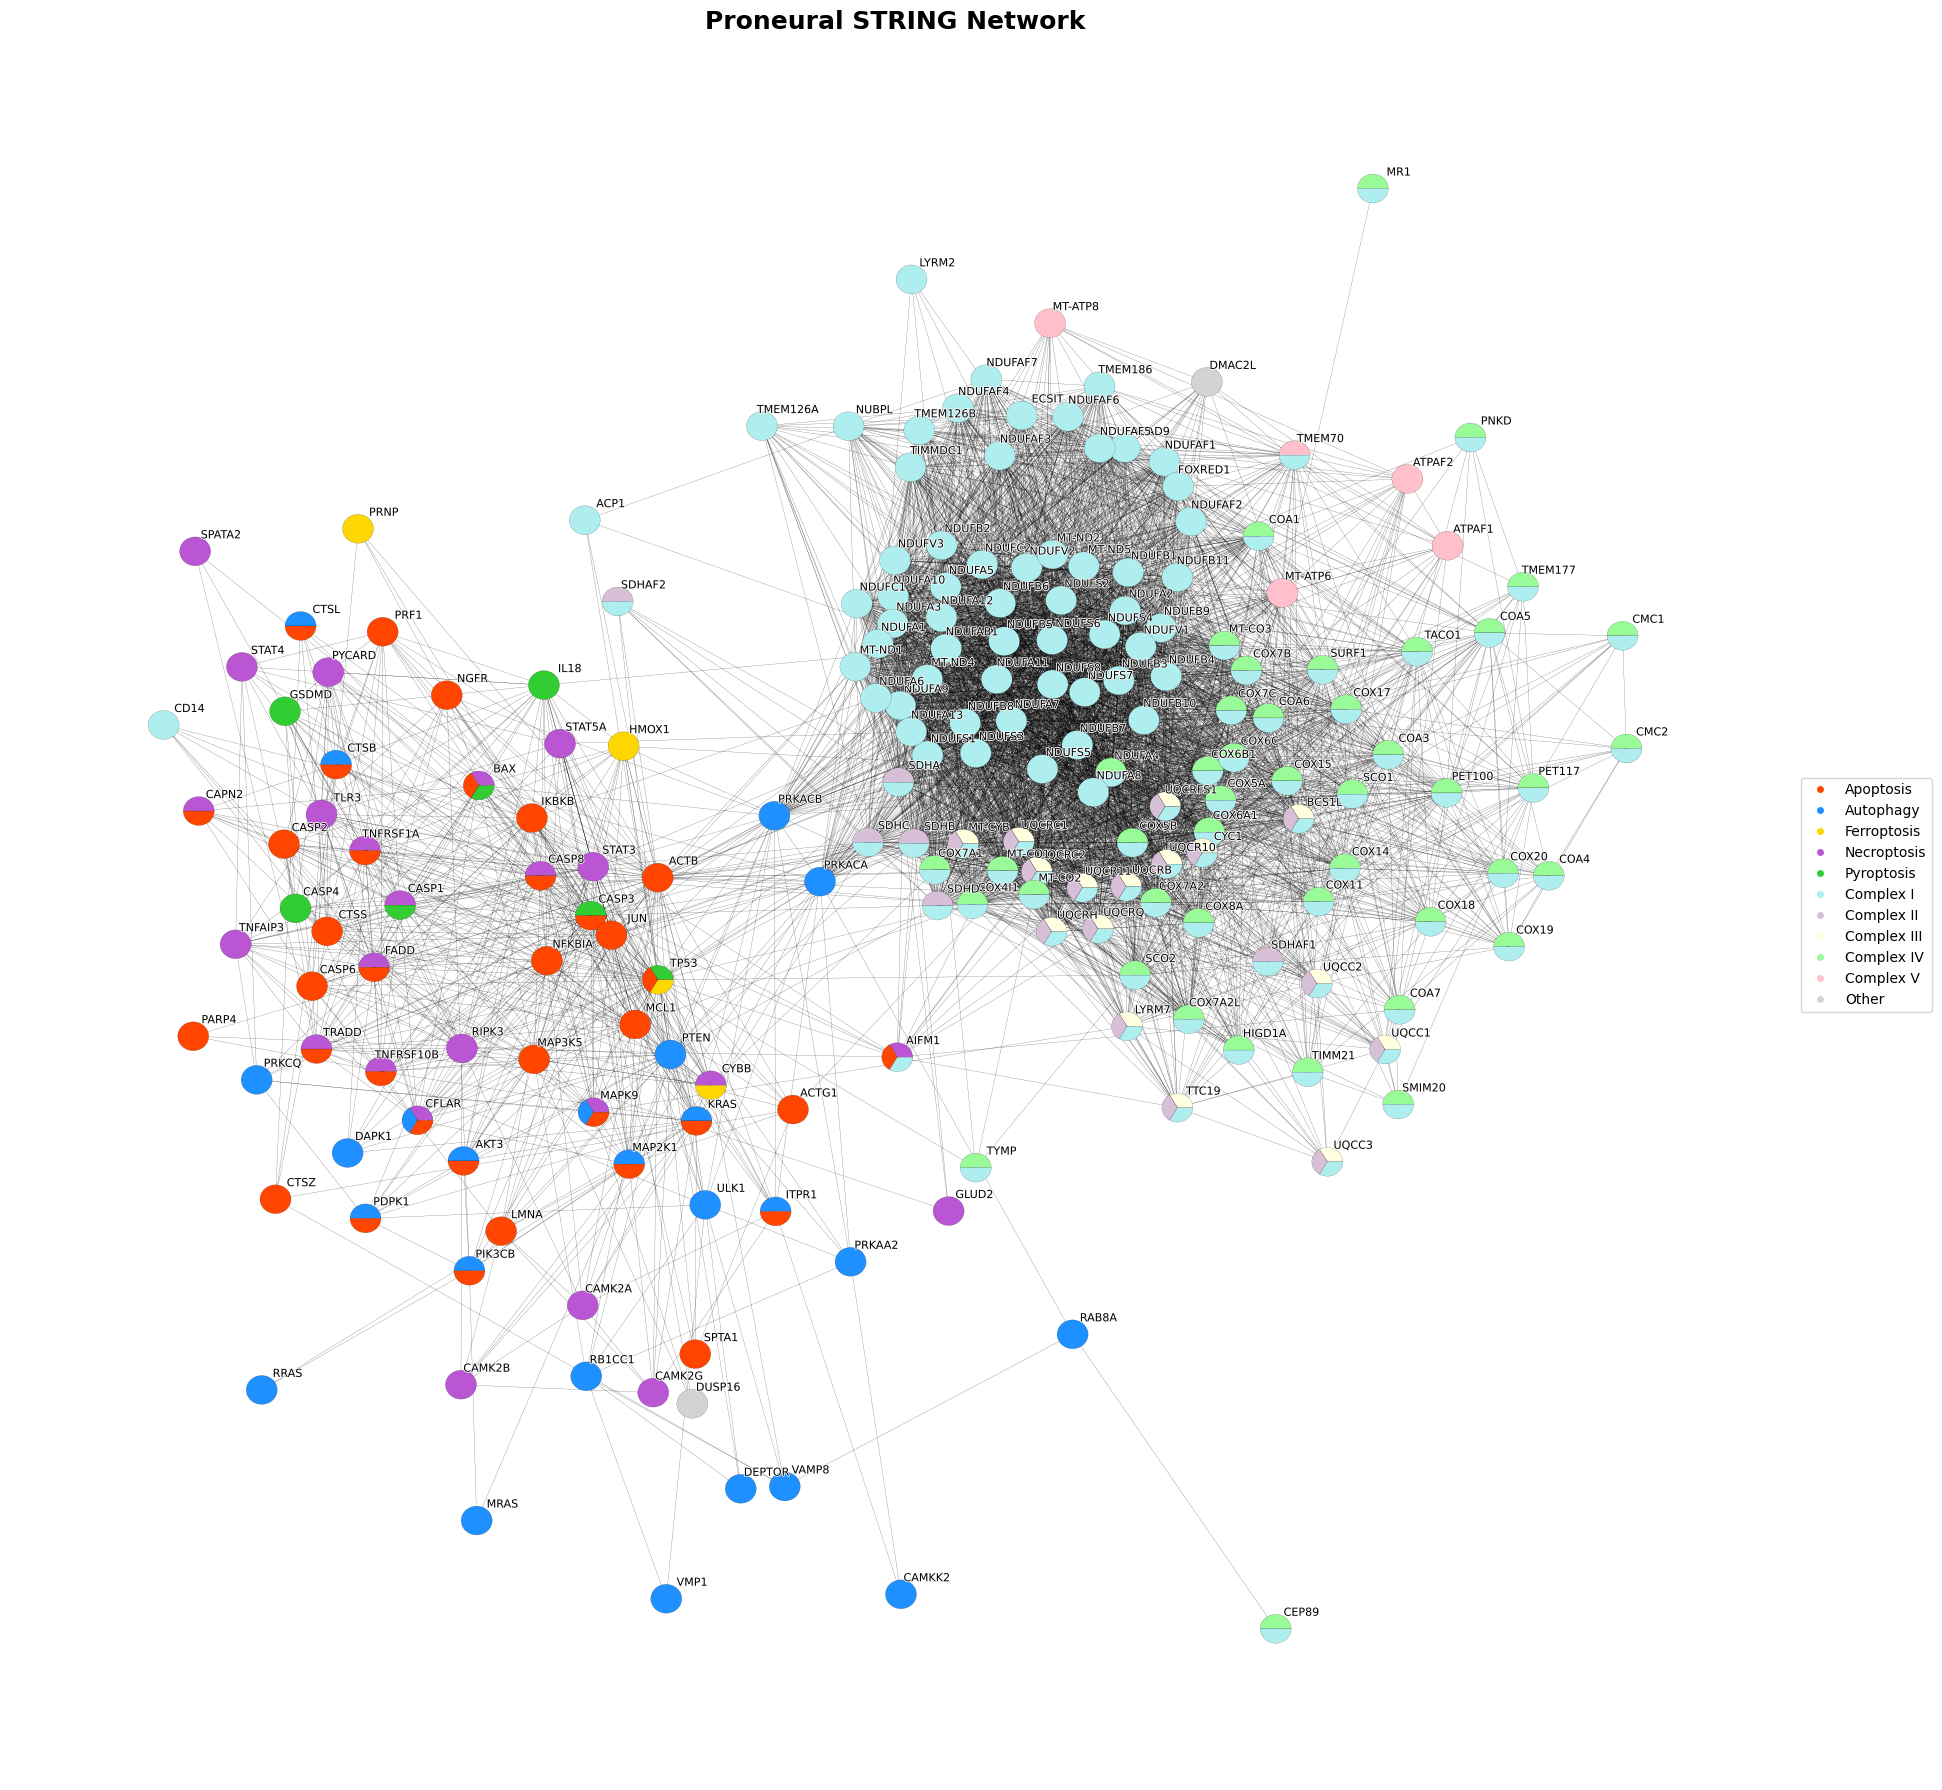

In [40]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patheffects as pe
from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D

# --------------------------------------------------
# COLORS
# --------------------------------------------------

pathway_colors = {
    "Apoptosis": "orangered",
    "Autophagy": "dodgerblue",
    "Ferroptosis": "gold",
    "Necroptosis": "mediumorchid",
    "Pyroptosis": "limegreen"
}

complex_colors = {
    "Complex I": "paleturquoise",
    "Complex II": "thistle",
    "Complex III": "lightyellow",
    "Complex IV": "palegreen",
    "Complex V": "pink"
}

radius = 0.018

# --------------------------------------------------
# LOOP THROUGH SUBTYPES
# --------------------------------------------------

for subtype in subtypes:

    G = graphs[subtype]

    pos = nx.kamada_kawai_layout(G)

    fig, ax = plt.subplots(
        figsize=(18,18)
    )

    ##################################################
    # Draw edges
    ##################################################

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="black",
        width=0.2,
        alpha=0.6,
        ax=ax
    )

    ##################################################
    # Draw nodes
    ##################################################

    for gene in G.nodes():

        x, y = pos[gene]

        colors = []

        # -------- Pathways --------

        for pathway in G.nodes[gene]["Pathways"]:

            if pathway in pathway_colors:

                colors.append(
                    pathway_colors[pathway]
                )

        # -------- Complexes --------

        for comp in G.nodes[gene]["Complexes"]:

            if comp in complex_colors:

                colors.append(
                    complex_colors[comp]
                )

        # -------- Draw --------

        if len(colors) == 0:

            node = Circle(
                (x,y),
                radius,
                facecolor="lightgray",
                edgecolor="black",
                linewidth=0.1
            )

            ax.add_patch(node)

        elif len(colors) == 1:

            node = Circle(
                (x,y),
                radius,
                facecolor=colors[0],
                edgecolor="black",
                linewidth=0.1
            )

            ax.add_patch(node)

        else:

            angle = 360 / len(colors)

            for i, color in enumerate(colors):

                wedge = Wedge(
                    (x,y),
                    radius,
                    theta1=i*angle,
                    theta2=(i+1)*angle,
                    facecolor=color,
                    edgecolor="black",
                    linewidth=0.1
                )

                ax.add_patch(wedge)

    ##################################################
    # Labels
    ##################################################

    label_pos = {
        gene:
        (
            xy[0] + 0.03,
            xy[1] + 0.02
        )
        for gene, xy in pos.items()
    }

    texts = nx.draw_networkx_labels(
        G,
        label_pos,
        labels={g:g for g in G.nodes()},
        font_size=8,
        font_color="black",
        font_family="sans-serif",
        ax=ax
    )

    for t in texts.values():

        t.set_path_effects([
            pe.Stroke(
                linewidth=1.2,
                foreground="white"
            ),
            pe.Normal()
        ])

    ##################################################
    # Legend
    ##################################################

    legend = [

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=pathway_colors["Apoptosis"],
            label="Apoptosis"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=pathway_colors["Autophagy"],
            label="Autophagy"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=pathway_colors["Ferroptosis"],
            label="Ferroptosis"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=pathway_colors["Necroptosis"],
            label="Necroptosis"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=pathway_colors["Pyroptosis"],
            label="Pyroptosis"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=complex_colors["Complex I"],
            label="Complex I"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=complex_colors["Complex II"],
            label="Complex II"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=complex_colors["Complex III"],
            label="Complex III"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=complex_colors["Complex IV"],
            label="Complex IV"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor=complex_colors["Complex V"],
            label="Complex V"
        ),

        Line2D(
            [0],[0],
            marker='o',
            color='w',
            markerfacecolor="lightgray",
            label="Other"
        )

    ]

    fig.legend(
        handles=legend,
        loc="center right",
        bbox_to_anchor=(1.08,0.5)
    )

    ##################################################
    # Finish
    ##################################################

    ax.set_title(
        f"{subtype.capitalize()} STRING Network",
        fontsize=18,
        fontweight="bold"
    )

    ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"../data/interim/network_stat/{subtype}_network.svg",
        format="svg",
        bbox_inches="tight"
    )

    plt.show()